In [43]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sys.path.append("../")
from src.features.nlp import *
from src.features.text_features import *
from src.features.skill_extraction import *
from src.features.numerical import *
from src.features.categorical import *

CELL 2: Thiết lập môi trường

In [44]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CELL 3: Đọc dữ liệu

In [77]:
DATA_PATH = r'D:\AI_LAB\DS_Job_Recommend_Projects\data\processed\postings_clean.csv'
data = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (123849, 31)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: We are seeking a College or Grad...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


CELL 4: Data inspection

In [46]:
data.info()
data.isna().sum().sort_values(ascending=False).head(20)

<class 'pandas.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  str    
 2   title                       123849 non-null  str    
 3   description                 123842 non-null  str    
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   str    
 6   location                    123849 non-null  str    
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6266 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  str    
 12  applies                     23320 non-null   float64
 13  original_listed_time     

closed_time                   122776
skills_desc                   121410
med_salary                    117583
applies                       100529
max_salary                     94056
min_salary                     94056
normalized_salary              87790
currency                       87776
compensation_type              87776
pay_period                     87776
posting_domain                 39968
application_url                36665
formatted_experience_level     29409
fips                           27415
zip_code                       20872
company_name                    1719
company_id                      1717
views                           1689
description                        7
listed_time                        0
dtype: int64

CELL 5: Target analysis

Target: formatted_experience_level
Number of classes: 6
Missing target values: 29409
Missing percentage: 23.74585180340576
formatted_experience_level
Mid-Senior level    41489
Entry level         36708
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64
formatted_experience_level
Mid-Senior level    43.93
Entry level         38.87
Associate           10.40
Director             3.97
Internship           1.53
Executive            1.29
Name: proportion, dtype: float64


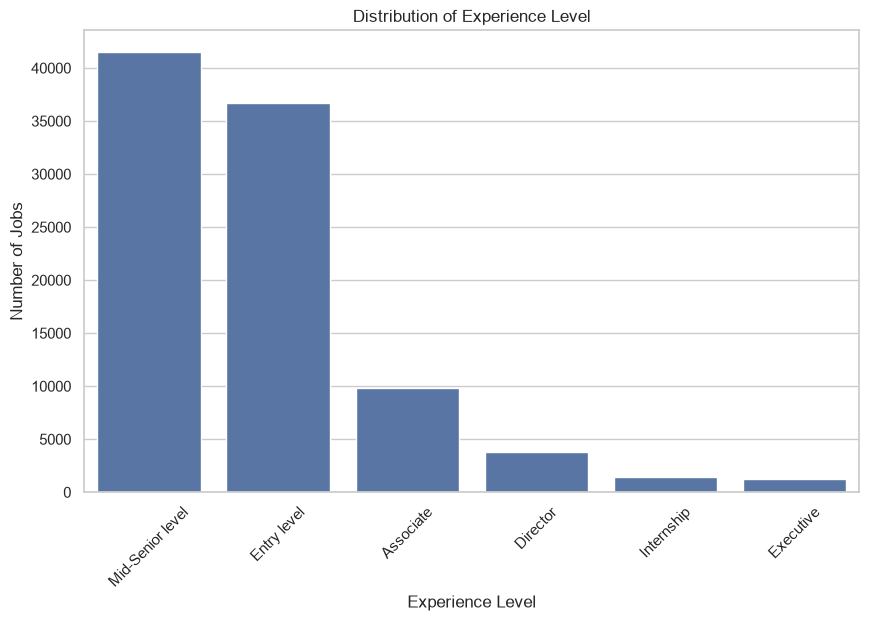

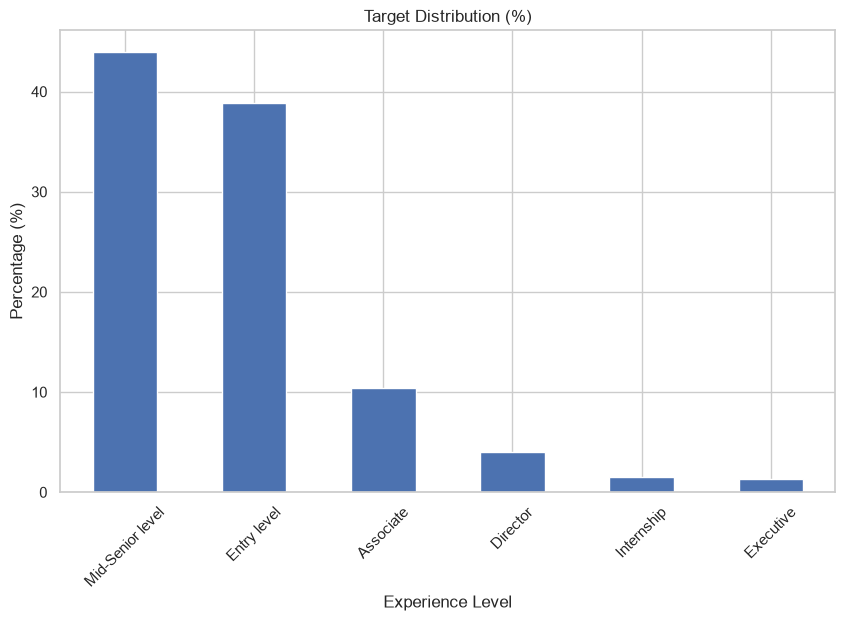

In [47]:
# Cell 5.1 — Xác định Target
TARGET = "formatted_experience_level"
print("Target:", TARGET)
print("Number of classes:", data[TARGET].nunique())
# Cell 5.2 — Kiểm tra missing target
print("Missing target values:", data[TARGET].isna().sum())
print("Missing percentage:", data[TARGET].isna().mean() * 100)
# Cell 5.3 — Phân bố Target
target_counts = data[TARGET].value_counts()
print(target_counts)
target_percentage = data[TARGET].value_counts(normalize=True) * 100
print(target_percentage.round(2))
# Cell 5.4 — Visualization
plt.figure(figsize=(10, 6))
sns.countplot(
    data=data,
    x=TARGET,
    order=data[TARGET].value_counts().index
)
plt.title("Distribution of Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=45)
plt.show()
# Cell 5.5 — Kiểm tra imbalance
target_percentage.plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Target Distribution (%)")
plt.xlabel("Experience Level")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.show()

CELL 6: Train/Test Split

In [48]:
from sklearn.model_selection import train_test_split
# Target
TARGET = "formatted_experience_level"
# Chỉ giữ những dòng có target
data_model = data.dropna(subset=[TARGET]).copy()
# Tách Features và Target
X = data_model.drop(columns=[TARGET])
y = data_model[TARGET]
print("Original dataset:", data.shape)
print("Dataset for modeling:", data_model.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("\nTrain/Test Split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Original dataset: (123849, 31)
Dataset for modeling: (94440, 31)
X shape: (94440, 30)
y shape: (94440,)

Train/Test Split:
X_train: (75552, 30)
X_test : (18888, 30)
y_train: (75552,)
y_test : (18888,)


CELL7: Text Preprocessing

In [49]:
# Text columns
TEXT_COLUMNS = [
    "title",
    "description",
    "skills_desc"
]

# Kiểm tra các cột text có tồn tại không
print("Text columns:")
for col in TEXT_COLUMNS:
    print(f"- {col}: {col in X_train.columns}")
    

Text columns:
- title: True
- description: True
- skills_desc: True


In [50]:
import re
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    # Remove numbers
    text = re.sub(r"\b\d+\b", " ", text)
    # Keep letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [51]:
# Tạo text tổng hợp
def combine_text_columns(data):
    text = (
        data["title"].fillna("").astype(str) + " " +
        data["description"].fillna("").astype(str) + " " +
        data["skills_desc"].fillna("").astype(str)
    )
    return text.apply(clean_text)

In [52]:
# Áp dụng cho Train và Test riêng biệt:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["combined_text"] = combine_text_columns(X_train)
X_test["combined_text"] = combine_text_columns(X_test)

In [53]:
# Kiểm tra:
print("Train text samples:")
display(X_train["combined_text"].head())

print("\nTest text samples:")
display(X_test["combined_text"].head())

Train text samples:


61929    warehouse supervisor make great pizza and more...
72826    cook we are a food market where you make the d...
40431    msl director east overview the msl field direc...
74113    utilization review specialist prn utilization ...
22154    studentische hilfskraft f r die durchf hrung v...
Name: combined_text, dtype: str


Test text samples:


40222     warehouse associate nd shift pick to pallet us...
109464    in store shopper a day in the life as the in s...
10808     latam and row content program sr manager bepc ...
83751     attorney employment defense litigation boutiqu...
54690     lvn bluitt flowers health center full time int...
Name: combined_text, dtype: str

CELL 8: TF-IDF

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)
X_train_tfidf = tfidf.fit_transform(
    X_train["combined_text"]
)

X_test_tfidf = tfidf.transform(
    X_test["combined_text"]
)
print("TF-IDF Train shape:", X_train_tfidf.shape)
print("TF-IDF Test shape :", X_test_tfidf.shape)
feature_names = tfidf.get_feature_names_out()
print("\nFirst 50 features:")
print(feature_names[:50])

TF-IDF Train shape: (75552, 30000)
TF-IDF Test shape : (18888, 30000)

First 50 features:
['aa' 'aa employer' 'aaa' 'ab' 'aba' 'abbott' 'abbvie' 'abc' 'abenity'
 'abenity consumer' 'abet' 'abet accredited' 'abide' 'abide cogent'
 'abides' 'abilities' 'abilities ability' 'abilities able'
 'abilities backgrounds' 'abilities demonstrated' 'abilities education'
 'abilities excellent' 'abilities experience' 'abilities internal'
 'abilities knowledge' 'abilities ksas' 'abilities required'
 'abilities skills' 'abilities strong' 'abilities talents' 'ability'
 'ability ability' 'ability access' 'ability accurately' 'ability achieve'
 'ability acquire' 'ability adapt' 'ability add' 'ability adjust'
 'ability analyze' 'ability anticipate' 'ability apply'
 'ability articulate' 'ability assess' 'ability balance' 'ability bend'
 'ability bring' 'ability build' 'ability calculate' 'ability clearly']


CELL 9: Skill Extraction

In [55]:
# ============================================================
# CELL 9 — SKILL EXTRACTION / SKILL AGGREGATION
# ============================================================

from collections import Counter


# ------------------------------------------------------------
# 1. Load job_skills dataset
# ------------------------------------------------------------

JOB_SKILLS_PATH = "../data/raw/job_skills.csv"

job_skills = pd.read_csv(JOB_SKILLS_PATH)

print("Job skills shape:", job_skills.shape)

print("\nColumns:")
print(job_skills.columns.tolist())

print("\nFirst 10 rows:")
display(job_skills.head(10))


# ------------------------------------------------------------
# 2. Basic data validation
# ------------------------------------------------------------

print("\nMissing values:")
print(job_skills.isna().sum())

print("\nDuplicated rows:")
print(job_skills.duplicated().sum())

print("\nUnique job IDs:")
print(job_skills["job_id"].nunique())

print("\nUnique skill categories:")
print(job_skills["skill_abr"].nunique())


# ------------------------------------------------------------
# 3. Remove invalid rows
# ------------------------------------------------------------

job_skills = job_skills.dropna(
    subset=["job_id", "skill_abr"]
).copy()

print("\nShape after removing missing skill information:")
print(job_skills.shape)


# ------------------------------------------------------------
# 4. Remove duplicated job-skill pairs
# ------------------------------------------------------------

job_skills = job_skills.drop_duplicates(
    subset=["job_id", "skill_abr"]
).copy()

print("\nShape after removing duplicate job-skill pairs:")
print(job_skills.shape)


# ------------------------------------------------------------
# 5. Skill frequency
# ------------------------------------------------------------

skill_frequency = (
    job_skills["skill_abr"]
    .value_counts()
)

print("\nTop 30 skill categories:")
display(skill_frequency.head(30))


# ------------------------------------------------------------
# 6. Aggregate skills by job_id
# ------------------------------------------------------------

job_skill_groups = (
    job_skills
    .groupby("job_id")["skill_abr"]
    .agg(list)
    .reset_index()
)

job_skill_groups.columns = [
    "job_id",
    "extracted_skills"
]

print("\nAggregated skills:")
display(job_skill_groups.head(10))


# ------------------------------------------------------------
# 7. Number of skills per job
# ------------------------------------------------------------

job_skill_groups["num_skills"] = (
    job_skill_groups["extracted_skills"]
    .apply(len)
)

print("\nSkill statistics:")
print(
    job_skill_groups["num_skills"].describe()
)


# ------------------------------------------------------------
# 8. Remove previous skill columns if Cell is re-run
# ------------------------------------------------------------

columns_to_remove = [
    "extracted_skills",
    "num_skills"
]

X_train = X_train.drop(
    columns=[
        col for col in columns_to_remove
        if col in X_train.columns
    ],
    errors="ignore"
)

X_test = X_test.drop(
    columns=[
        col for col in columns_to_remove
        if col in X_test.columns
    ],
    errors="ignore"
)


# ------------------------------------------------------------
# 9. Merge skills into training data
# ------------------------------------------------------------

X_train = X_train.merge(
    job_skill_groups,
    on="job_id",
    how="left"
)


# ------------------------------------------------------------
# 10. Merge skills into test data
# ------------------------------------------------------------

X_test = X_test.merge(
    job_skill_groups,
    on="job_id",
    how="left"
)


# ------------------------------------------------------------
# 11. Handle jobs without skill information
# ------------------------------------------------------------

X_train["extracted_skills"] = (
    X_train["extracted_skills"]
    .apply(
        lambda x: x if isinstance(x, list) else []
    )
)

X_test["extracted_skills"] = (
    X_test["extracted_skills"]
    .apply(
        lambda x: x if isinstance(x, list) else []
    )
)


# ------------------------------------------------------------
# 12. Create number-of-skills feature
# ------------------------------------------------------------

X_train["num_skills"] = (
    X_train["extracted_skills"]
    .apply(len)
)

X_test["num_skills"] = (
    X_test["extracted_skills"]
    .apply(len)
)


# ------------------------------------------------------------
# 13. Check training data
# ------------------------------------------------------------

print("\nTrain skill features:")

display(
    X_train[
        [
            "job_id",
            "title",
            "extracted_skills",
            "num_skills"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 14. Check test data
# ------------------------------------------------------------

print("\nTest skill features:")

display(
    X_test[
        [
            "job_id",
            "title",
            "extracted_skills",
            "num_skills"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 15. Skill coverage
# ------------------------------------------------------------

train_jobs_with_skills = (
    X_train["extracted_skills"]
    .apply(len)
    .gt(0)
    .sum()
)

test_jobs_with_skills = (
    X_test["extracted_skills"]
    .apply(len)
    .gt(0)
    .sum()
)

print("\nSkill Coverage")
print("-" * 40)

print(
    f"Train jobs with skills: "
    f"{train_jobs_with_skills} / {len(X_train)} "
    f"({train_jobs_with_skills / len(X_train) * 100:.2f}%)"
)

print(
    f"Test jobs with skills : "
    f"{test_jobs_with_skills} / {len(X_test)} "
    f"({test_jobs_with_skills / len(X_test) * 100:.2f}%)"
)


# ------------------------------------------------------------
# 16. Top skills in training data
# ------------------------------------------------------------

all_train_skills = []

for skills in X_train["extracted_skills"]:
    all_train_skills.extend(skills)

skill_counts = Counter(all_train_skills)

print("\nTop 30 skills in training data:")

for skill, count in skill_counts.most_common(30):
    print(f"{skill:<10} : {count}")

Job skills shape: (213768, 2)

Columns:
['job_id', 'skill_abr']

First 10 rows:


,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN
5,3887465684,SALE
6,3887467939,SALE
7,3887467939,ADVR
8,3887467939,BD
9,3887471331,ENG



Missing values:
job_id       0
skill_abr    0
dtype: int64

Duplicated rows:
0

Unique job IDs:
126807

Unique skill categories:
35

Shape after removing missing skill information:
(213768, 2)

Shape after removing duplicate job-skill pairs:
(213768, 2)

Top 30 skill categories:


skill_abr
IT      26137
SALE    22475
MGMT    20861
MNFC    18185
HCPR    17369
BD      14290
ENG     13009
OTHR    12608
FIN      8540
MRKT     5525
ACCT     5461
ADM      4860
CUST     4292
PRJM     3997
ANLS     3858
RSCH     2986
HR       2647
LGL      2371
CNSL     2338
EDU      2290
DSGN     2244
TRNG     2243
GENB     1984
QA       1791
ART      1664
WRT      1443
PRDM     1362
PR       1298
SUPL     1180
STRA     1178
Name: count, dtype: int64


Aggregated skills:


...


Skill statistics:
count    126807.000000
mean          1.685774
std           0.675907
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           3.000000
Name: num_skills, dtype: float64

Train skill features:


,job_id,title,extracted_skills,num_skills
0,3901998528,Warehouse Supervisor,[SUPL],1
1,3902911720,Cook,"[MGMT, MNFC]",2
2,3898173167,"MSL Director, East",[OTHR],1
3,3902946417,Utilization Review Specialist (PRN),[OTHR],1
4,3889703356,Studentische Hilfskraft für die Durchführung v...,[ADM],1
5,3885848414,Traffic Clerk at Guard Shack,[OTHR],1
6,3901177302,Compliance Environmental Scientist / Engineer,"[DSGN, SCI, ENG]",3
7,3905292024,Resource Pool Clinical Associate,"[RSCH, ANLS, IT]",3
8,3903809709,Food Runners,"[MGMT, MNFC]",2
9,3904367796,Client Service Support Representative,[OTHR],1



Test skill features:


,job_id,title,extracted_skills,num_skills
0,3898171835,Warehouse Associate - 2nd Shift Pick to Pallet...,"[MGMT, MNFC]",2
1,3905361596,In-Store Shopper,"[MRKT, SALE]",2
2,3887467924,LATAM and ROW Content Program Sr. Manager,[MRKT],1
3,3904082992,Attorney - Employment Defense Litigation - Bou...,[LGL],1
4,3901686553,LVN - Bluitt Flowers Health Center - Full Time,[HCPR],1
5,3904377351,Account Director,"[SALE, BD]",2
6,3904726289,Travel LPN - Job Id: JO03721777,[HCPR],1
7,3901960616,Cons Bnkng Relationship Spec (Relationship Ban...,[OTHR],1
8,3902751691,Clinic Admissions Associate,[ADM],1
9,3894864982,Project Engineer,"[ENG, IT]",2



Skill Coverage
----------------------------------------
Train jobs with skills: 75552 / 75552 (100.00%)
Test jobs with skills : 18888 / 18888 (100.00%)

Top 30 skills in training data:
IT         : 15270
MGMT       : 13114
SALE       : 12709
MNFC       : 11260
HCPR       : 10182
BD         : 8126
ENG        : 7504
OTHR       : 7326
FIN        : 4991
ACCT       : 3345
MRKT       : 3293
ADM        : 3140
CUST       : 2955
PRJM       : 2575
ANLS       : 2350
RSCH       : 1656
HR         : 1613
CNSL       : 1502
GENB       : 1370
TRNG       : 1358
EDU        : 1346
DSGN       : 1335
LGL        : 1282
QA         : 1116
ART        : 918
PRDM       : 846
STRA       : 801
WRT        : 778
SUPL       : 755
PR         : 672


CELL 10 — MULTI-HOT ENCODING SKILLS

In [56]:
# ============================================================
# CELL 10 — MULTI-HOT ENCODING SKILLS
# ============================================================

from sklearn.preprocessing import MultiLabelBinarizer

# ------------------------------------------------------------
# 1. Khởi tạo encoder
# ------------------------------------------------------------

mlb = MultiLabelBinarizer()

# ------------------------------------------------------------
# 2. Fit trên TRAIN và transform TRAIN
# ------------------------------------------------------------

X_train_skills = mlb.fit_transform(
    X_train["extracted_skills"]
)

# ------------------------------------------------------------
# 3. Transform TEST
# ------------------------------------------------------------

X_test_skills = mlb.transform(
    X_test["extracted_skills"]
)

# ------------------------------------------------------------
# 4. Kiểm tra kích thước
# ------------------------------------------------------------

print("Train skill matrix shape:", X_train_skills.shape)
print("Test skill matrix shape :", X_test_skills.shape)

print("\nNumber of skill features:")
print(len(mlb.classes_))

# ------------------------------------------------------------
# 5. Xem tên các skill features
# ------------------------------------------------------------

print("\nFirst 50 skill features:")
print(mlb.classes_[:50])

Train skill matrix shape: (75552, 35)
Test skill matrix shape : (18888, 35)

Number of skill features:
35

First 50 skill features:
['ACCT' 'ADM' 'ADVR' 'ANLS' 'ART' 'BD' 'CNSL' 'CUST' 'DIST' 'DSGN' 'EDU'
 'ENG' 'FIN' 'GENB' 'HCPR' 'HR' 'IT' 'LGL' 'MGMT' 'MNFC' 'MRKT' 'OTHR'
 'PR' 'PRCH' 'PRDM' 'PRJM' 'PROD' 'QA' 'RSCH' 'SALE' 'SCI' 'STRA' 'SUPL'
 'TRNG' 'WRT']


CELL 11 — KIỂM TRA num_skills

Train num_skills statistics:


count    75552.000000
mean         1.689512
std          0.685330
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: num_skills, dtype: float64


Test num_skills statistics:


count    18888.000000
mean         1.685991
std          0.682381
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: num_skills, dtype: float64

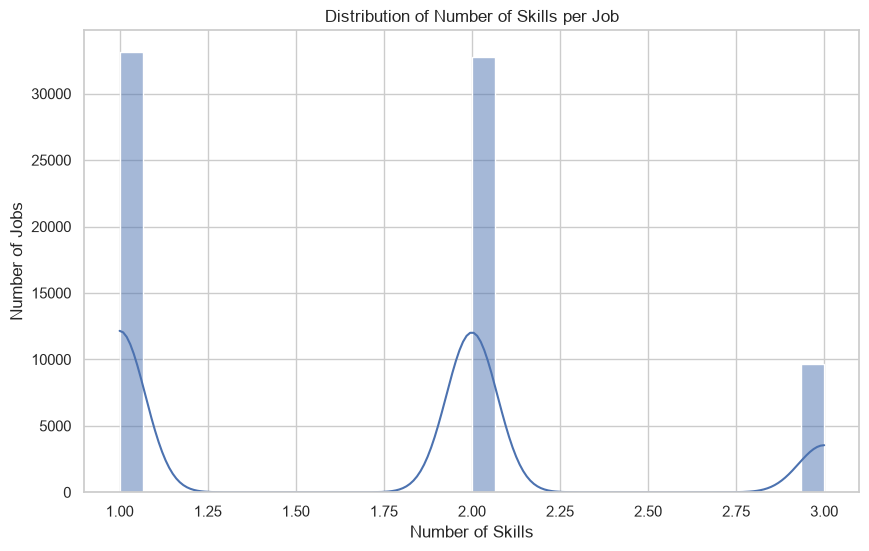

In [57]:
# ============================================================
# CELL 11 — SKILL COUNT ANALYSIS
# ============================================================

print("Train num_skills statistics:")
display(X_train["num_skills"].describe())

print("\nTest num_skills statistics:")
display(X_test["num_skills"].describe())

plt.figure(figsize=(10, 6))

sns.histplot(
    X_train["num_skills"],
    bins=30,
    kde=True
)

plt.title("Distribution of Number of Skills per Job")
plt.xlabel("Number of Skills")
plt.ylabel("Number of Jobs")

plt.show()

CELL 12 — COMBINE SKILL FEATURES

In [58]:
print("TF-IDF:")
print(X_train_tfidf.shape)

print("\nSkill multi-hot:")
print(X_train_skills.shape)

print("\nNumerical skill count:")
print(X_train["num_skills"].shape)

TF-IDF:
(75552, 30000)

Skill multi-hot:
(75552, 35)

Numerical skill count:
(75552,)


CELL 13 — NUMERICAL FEATURES

In [59]:
# ============================================================
# CELL 13 — NUMERICAL FEATURES
# ============================================================

NUMERICAL_COLUMNS = [
    "min_salary",
    "med_salary",
    "max_salary",
    "normalized_salary",
    "num_skills"
]

print("Numerical columns:")

for col in NUMERICAL_COLUMNS:
    if col in X_train.columns:
        print(f"✓ {col}")
    else:
        print(f"✗ {col} NOT FOUND")

X_train_numeric = X_train[NUMERICAL_COLUMNS].copy()
X_test_numeric = X_test[NUMERICAL_COLUMNS].copy()

print("Train numerical shape:", X_train_numeric.shape)
print("Test numerical shape :", X_test_numeric.shape)

display(X_train_numeric.head())

Numerical columns:
✓ min_salary
✓ med_salary
✓ max_salary
✓ normalized_salary
✓ num_skills
Train numerical shape: (75552, 5)
Test numerical shape : (18888, 5)


,min_salary,med_salary,max_salary,normalized_salary,num_skills
0,NaN,NaN,NaN,NaN,1
1,16.0,NaN,17.0,34320.0,2
2,NaN,NaN,NaN,NaN,1
3,NaN,NaN,NaN,NaN,1
4,NaN,NaN,NaN,NaN,1


CELL 14 — HANDLE NUMERICAL MISSING VALUES

In [60]:
# ============================================================
# CELL 14 — NUMERICAL IMPUTATION
# ============================================================

from sklearn.impute import SimpleImputer

numeric_imputer = SimpleImputer(
    strategy="median"
)

X_train_numeric_imputed = numeric_imputer.fit_transform(
    X_train_numeric
)

X_test_numeric_imputed = numeric_imputer.transform(
    X_test_numeric
)

print(
    "Train numerical shape:",
    X_train_numeric_imputed.shape
)

print(
    "Test numerical shape:",
    X_test_numeric_imputed.shape
)

Train numerical shape: (75552, 5)
Test numerical shape: (18888, 5)


CELL 15 — Outlier Analysis

Numerical features:
['min_salary', 'med_salary', 'max_salary', 'normalized_salary', 'num_skills']


,count,mean,std,min,25%,50%,75%,max
min_salary,18405.0,62116.624923,63332.242032,1.0,35.00,60062.180,100000.00,750000.0
med_salary,3936.0,23487.968786,55297.780062,10.0,18.75,25.735,2891.75,750000.0
max_salary,18405.0,86451.862216,92831.769181,1.0,45.00,80000.000,140000.00,1220000.0
normalized_salary,22341.0,97625.303101,65638.217015,120.0,52500.00,84240.000,126006.40,2096744.0
num_skills,75552.0,1.689512,0.685330,1.0,1.00,2.000,2.00,3.0


,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percentage
0,min_salary,35.00,100000.00,99965.0,-149912.50,249947.50,196,0.259424
1,med_salary,18.75,2891.75,2873.0,-4290.75,7201.25,955,1.264030
2,max_salary,45.00,140000.00,139955.0,-209887.50,349932.50,217,0.287219
3,normalized_salary,52500.00,126006.40,73506.4,-57759.60,236266.00,556,0.735917
4,num_skills,1.00,2.00,1.0,-0.50,3.50,0,0.000000


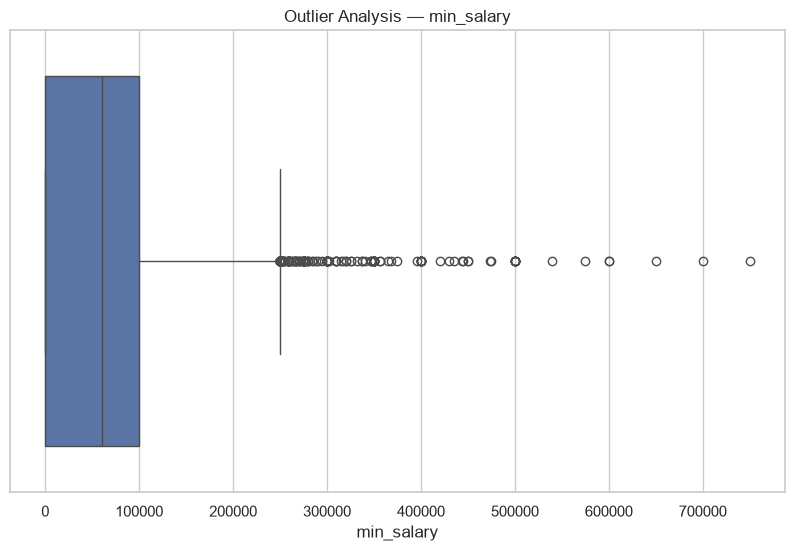

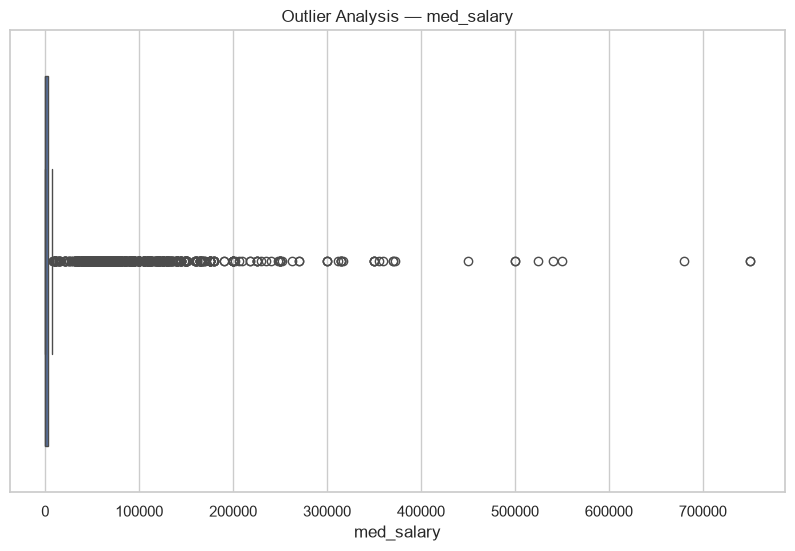

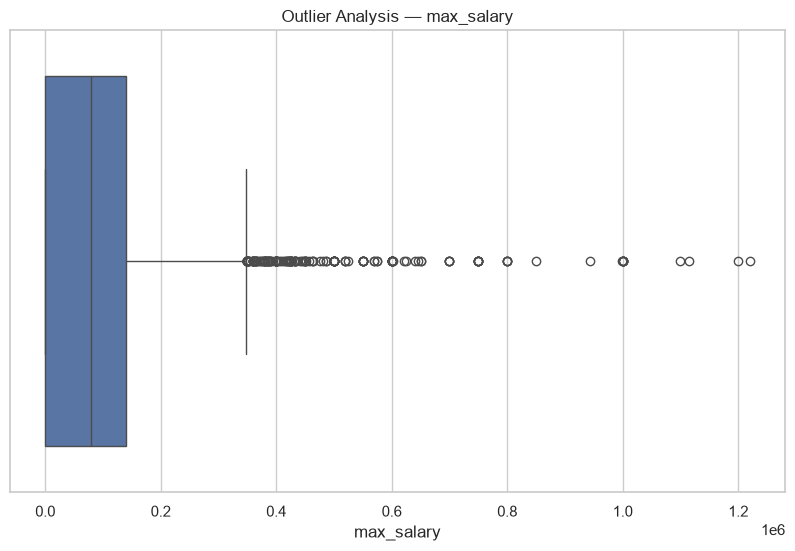

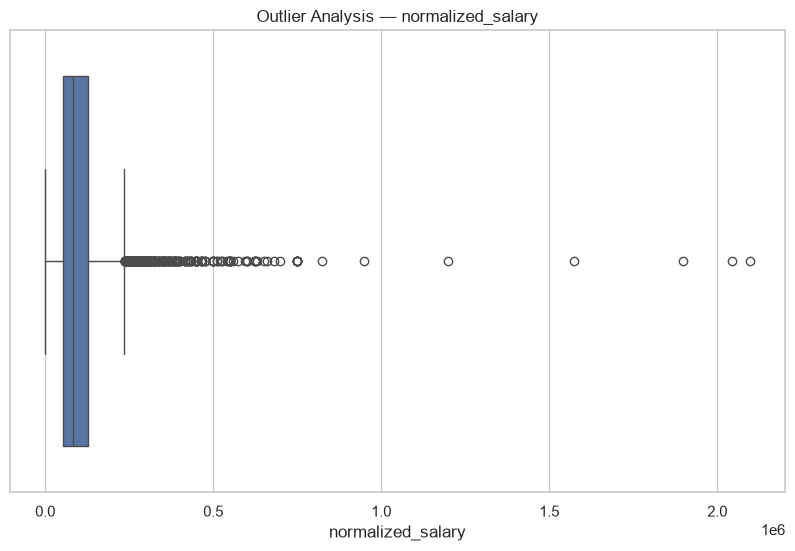

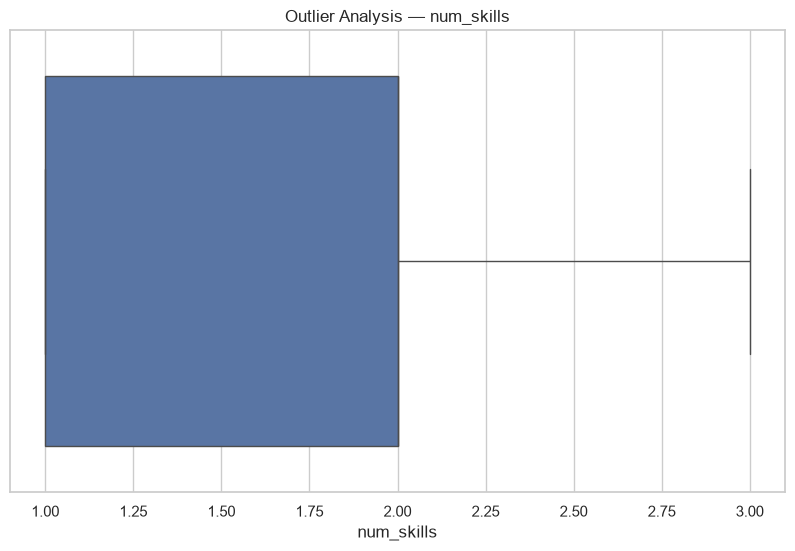

In [63]:
NUMERICAL_COLUMNS = [
    "min_salary",
    "med_salary",
    "max_salary",
    "normalized_salary",
    "num_skills"
]
# Chỉ lấy những cột thực sự tồn tại
available_numeric = [
    col for col in NUMERICAL_COLUMNS
    if col in X_train.columns
]
print("Numerical features:")
print(available_numeric)
# thống kê:
display(
    X_train[available_numeric].describe().T
)
# Phát hiện outlier bằng IQR
outlier_summary = []
for col in available_numeric:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (
        (X_train[col] < lower_bound) |
        (X_train[col] > upper_bound)
    )
    outlier_count = outliers.sum()
    outlier_percentage = (
        outlier_count / len(X_train) * 100
    )
    outlier_summary.append({
        "feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage
    })
outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary)
# visualize
for col in available_numeric:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=X_train[col])
    plt.title(f"Outlier Analysis — {col}")
    plt.xlabel(col)
    plt.show()

CELL 16 — Categorical Features

In [64]:
# ------------------------------------------------------------
# 1. Xác định các categorical columns
# ------------------------------------------------------------
CATEGORICAL_COLUMNS = [
    "formatted_work_type",
    "remote_allowed",
    "application_type",
    "experience_level",
    "workplace_type",
    "company_size",
    "location"
]
# Chỉ giữ những cột thực sự tồn tại
available_categorical = [
    col for col in CATEGORICAL_COLUMNS
    if col in X_train.columns
]
print("Categorical features:")
for col in available_categorical:
    print(f"✓ {col}")
print("\nNumber of categorical features:", len(available_categorical))

# Kiểm tra kiểu dữ liệu
print("Data types:")
display(
    X_train[available_categorical].dtypes.to_frame("dtype")
)
# Kiểm tra missing values
categorical_missing = (
    X_train[available_categorical]
    .isna()
    .sum()
    .sort_values(ascending=False)
)
display(
    categorical_missing.to_frame("missing_count")
)
# Tính phần trăm:
categorical_missing_pct = (
    X_train[available_categorical]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)
display(
    categorical_missing_pct.to_frame("missing_percentage")
)
# Kiểm tra số lượng category
categorical_summary = []
for col in available_categorical:
    categorical_summary.append({
        "feature": col,
        "unique_values": X_train[col].nunique(dropna=True),
        "missing_values": X_train[col].isna().sum()
    })
categorical_summary = pd.DataFrame(
    categorical_summary
)
display(categorical_summary)
# Xem phân phối từng categorical feature
for col in available_categorical:
    print("\n" + "=" * 60)
    print(f"Feature: {col}")
    print("=" * 60)
    display(
        X_train[col]
        .value_counts(dropna=False)
        .head(20)
        .to_frame("count")
    )
# Đặc biệt kiểm tra location
if "location" in X_train.columns:
    print("Number of unique locations:")
    print(X_train["location"].nunique())
    print("\nTop 30 locations:")
    display(
        X_train["location"]
        .value_counts()
        .head(30)
        .to_frame("count")
    )

Categorical features:
✓ formatted_work_type
✓ remote_allowed
✓ application_type
✓ location

Number of categorical features: 4
Data types:


,dtype
formatted_work_type,str
remote_allowed,int64
application_type,str
location,str


,missing_count
formatted_work_type,0
remote_allowed,0
application_type,0
location,0


,missing_percentage
formatted_work_type,0.0
remote_allowed,0.0
application_type,0.0
location,0.0


,feature,unique_values,missing_values
0,formatted_work_type,7,0
1,remote_allowed,2,0
2,application_type,4,0
3,location,7146,0


...

,count
application_type,
OffsiteApply,54652
ComplexOnsiteApply,17156
SimpleOnsiteApply,3743
UnknownApply,1



Feature: location


,count
location,
United States,4248
"New York, NY",1684
"Chicago, IL",1112
"Houston, TX",1093
"Dallas, TX",862
"Atlanta, GA",820
"Boston, MA",754
"Charlotte, NC",640
"Phoenix, AZ",634


Number of unique locations:
7146

Top 30 locations:


,count
location,
United States,4248
"New York, NY",1684
"Chicago, IL",1112
"Houston, TX",1093
"Dallas, TX",862
"Atlanta, GA",820
"Boston, MA",754
"Charlotte, NC",640
"Phoenix, AZ",634


CELL 17 — Categorical Encoding

In [65]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
# ------------------------------------------------------------
# 1. Lấy categorical features
# ------------------------------------------------------------
X_train_cat = X_train[available_categorical].copy()
X_test_cat = X_test[available_categorical].copy()
print("Train categorical shape:", X_train_cat.shape)
print("Test categorical shape :", X_test_cat.shape)

# ------------------------------------------------------------
# 2. Handle missing categorical values
# ------------------------------------------------------------
categorical_imputer = SimpleImputer(
    strategy="constant",
    fill_value="Unknown"
)
X_train_cat_imputed = categorical_imputer.fit_transform(
    X_train_cat
)
X_test_cat_imputed = categorical_imputer.transform(
    X_test_cat
)
print("Train after imputation:", X_train_cat_imputed.shape)
print("Test after imputation :", X_test_cat_imputed.shape)

# ------------------------------------------------------------
# 3. One-Hot Encoding
# ------------------------------------------------------------
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)
X_train_cat_encoded = categorical_encoder.fit_transform(
    X_train_cat_imputed
)
X_test_cat_encoded = categorical_encoder.transform(
    X_test_cat_imputed
)
print("Encoded train shape:", X_train_cat_encoded.shape)
print("Encoded test shape :", X_test_cat_encoded.shape)

# ------------------------------------------------------------
# 4. Feature names
# ------------------------------------------------------------
categorical_feature_names = (
    categorical_encoder
    .get_feature_names_out(available_categorical)
)
print("Number of categorical features:")
print(len(categorical_feature_names))
print("\nFirst 50 categorical features:")
print(
    categorical_feature_names[:50]
)

# ------------------------------------------------------------
# 5. Inspect encoded matrix
# ------------------------------------------------------------
print("Train encoded matrix:")
print(X_train_cat_encoded)
print("\nTest encoded matrix:")
print(X_test_cat_encoded)
# Kiểm tra số lượng feature
print(
    f"\nCategorical features created: "
    f"{X_train_cat_encoded.shape[1]}"
)

Train categorical shape: (75552, 4)
Test categorical shape : (18888, 4)
Train after imputation: (75552, 4)
Test after imputation : (18888, 4)
Encoded train shape: (75552, 7159)
Encoded test shape : (18888, 7159)
Number of categorical features:
7159

First 50 categorical features:
['formatted_work_type_Contract' 'formatted_work_type_Full-time'
 'formatted_work_type_Internship' 'formatted_work_type_Other'
 'formatted_work_type_Part-time' 'formatted_work_type_Temporary'
 'formatted_work_type_Volunteer' 'remote_allowed_0' 'remote_allowed_1'
 'application_type_ComplexOnsiteApply' 'application_type_OffsiteApply'
 'application_type_SimpleOnsiteApply' 'application_type_UnknownApply'
 'location_Abbeville, LA' 'location_Abbeville, SC'
 'location_Abbotsford, WI' 'location_Abbott, TX'
 'location_Aberdeen Proving Ground, MD' 'location_Aberdeen, MD'
 'location_Aberdeen, NC' 'location_Aberdeen, WA' 'location_Abilene, KS'
 'location_Abilene, TX' 'location_Abingdon, MD' 'location_Abingdon, VA'
 'locati

CELL 18 — Temporal Features

Available temporal columns:
✓ listed_time
✓ original_listed_time
✓ expiry
✓ closed_time

Number of temporal columns: 4
Temporal data types:


,dtype
listed_time,datetime64[ns]
original_listed_time,float64
expiry,float64
closed_time,float64


listed_time converted successfully.

Train dtype:
datetime64[ns]

Test dtype:
datetime64[ns]
Temporal features created successfully.
is_weekend created.


,job_id,listed_time,listed_year,listed_month,listed_day,listed_dayofweek,listed_hour,is_weekend
0,3901998528,1970-01-01 00:28:33.499516,1970,1,1,3,0,0
1,3902911720,1970-01-01 00:28:33.277285,1970,1,1,3,0,0
2,3898173167,1970-01-01 00:28:33.213856,1970,1,1,3,0,0
3,3902946417,1970-01-01 00:28:33.281234,1970,1,1,3,0,0
4,3889703356,1970-01-01 00:28:32.660414,1970,1,1,3,0,0
5,3885848414,1970-01-01 00:28:32.397300,1970,1,1,3,0,0
6,3901177302,1970-01-01 00:28:33.280113,1970,1,1,3,0,0
7,3905292024,1970-01-01 00:28:33.472281,1970,1,1,3,0,0
8,3903809709,1970-01-01 00:28:33.471991,1970,1,1,3,0,0
9,3904367796,1970-01-01 00:28:33.391743,1970,1,1,3,0,0


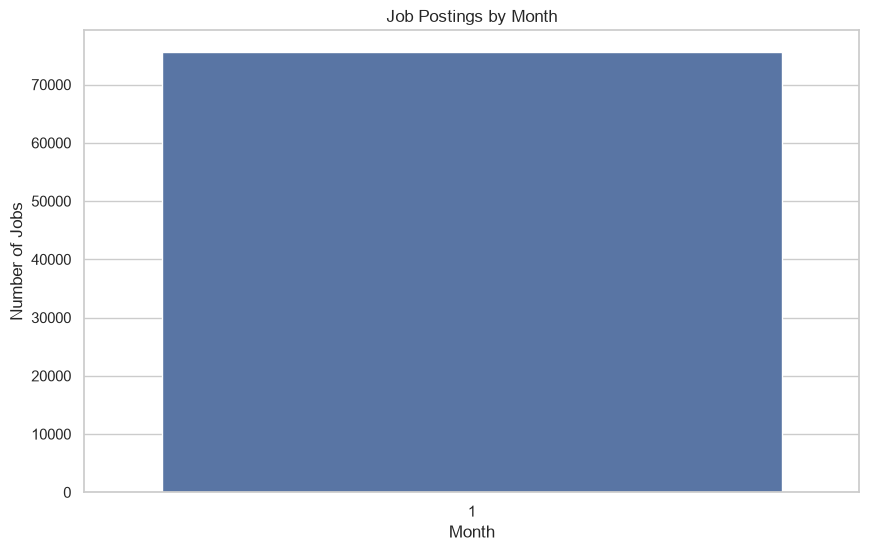

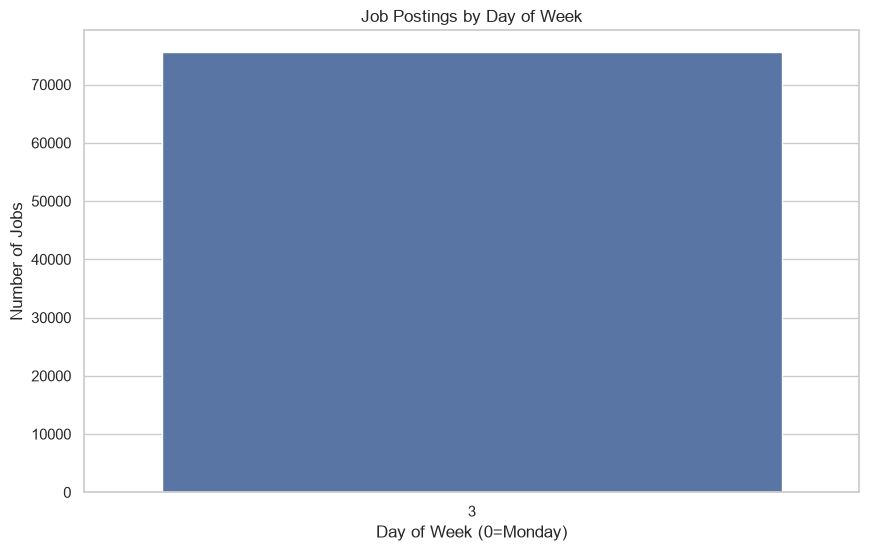

Raw listed_time removed.


In [67]:
# ------------------------------------------------------------
# 1. Kiểm tra các cột thời gian
# ------------------------------------------------------------
TIME_COLUMNS = [
    "listed_time",
    "original_listed_time",
    "expiry",
    "closed_time"
]
available_time_columns = [
    col for col in TIME_COLUMNS
    if col in X_train.columns
]
print("Available temporal columns:")
for col in available_time_columns:
    print(f"✓ {col}")
print("\nNumber of temporal columns:", len(available_time_columns))

# ------------------------------------------------------------
# 2. Check data types
# ------------------------------------------------------------
print("Temporal data types:")
display(
    X_train[available_time_columns]
    .dtypes
    .to_frame("dtype")
)

# ------------------------------------------------------------
# 3. Convert listed_time
# ------------------------------------------------------------
if "listed_time" in X_train.columns:
    X_train["listed_time"] = pd.to_datetime(
        X_train["listed_time"],
        errors="coerce"
    )
    X_test["listed_time"] = pd.to_datetime(
        X_test["listed_time"],
        errors="coerce"
    )
    print("listed_time converted successfully.")
    print("\nTrain dtype:")
    print(X_train["listed_time"].dtype)
    print("\nTest dtype:")
    print(X_test["listed_time"].dtype)

# ------------------------------------------------------------
# 4. Extract temporal features
# ------------------------------------------------------------
if "listed_time" in X_train.columns:
    # Year
    X_train["listed_year"] = X_train["listed_time"].dt.year
    X_test["listed_year"] = X_test["listed_time"].dt.year
    # Month
    X_train["listed_month"] = X_train["listed_time"].dt.month
    X_test["listed_month"] = X_test["listed_time"].dt.month
    # Day
    X_train["listed_day"] = X_train["listed_time"].dt.day
    X_test["listed_day"] = X_test["listed_time"].dt.day
    # Day of week
    X_train["listed_dayofweek"] = X_train["listed_time"].dt.dayofweek
    X_test["listed_dayofweek"] = X_test["listed_time"].dt.dayofweek
    # Hour
    X_train["listed_hour"] = X_train["listed_time"].dt.hour
    X_test["listed_hour"] = X_test["listed_time"].dt.hour
    print("Temporal features created successfully.")

# ------------------------------------------------------------
# 5. Weekend feature
# ------------------------------------------------------------
if "listed_dayofweek" in X_train.columns:
    X_train["is_weekend"] = (
        X_train["listed_dayofweek"] >= 5
    ).astype(int)
    X_test["is_weekend"] = (
        X_test["listed_dayofweek"] >= 5
    ).astype(int)
    print("is_weekend created.")

# ------------------------------------------------------------
# 6. Inspect temporal features
# ------------------------------------------------------------
temporal_features = [
    "listed_year",
    "listed_month",
    "listed_day",
    "listed_dayofweek",
    "listed_hour",
    "is_weekend"
]
available_temporal_features = [
    col for col in temporal_features
    if col in X_train.columns
]
display(
    X_train[
        ["job_id", "listed_time"] +
        available_temporal_features
    ].head(10)
)

# ------------------------------------------------------------
# 7. Job postings by month
# ------------------------------------------------------------

if "listed_month" in X_train.columns:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=X_train,
        x="listed_month"
    )

    plt.title("Job Postings by Month")
    plt.xlabel("Month")
    plt.ylabel("Number of Jobs")

    plt.show()

# ------------------------------------------------------------
# 8. Job postings by day of week
# ------------------------------------------------------------

if "listed_dayofweek" in X_train.columns:

    plt.figure(figsize=(10, 6))

    sns.countplot(
        data=X_train,
        x="listed_dayofweek"
    )

    plt.title("Job Postings by Day of Week")
    plt.xlabel("Day of Week (0=Monday)")
    plt.ylabel("Number of Jobs")

    plt.show()

# ------------------------------------------------------------
# 9. Remove raw datetime column
# ------------------------------------------------------------

X_train = X_train.drop(
    columns=["listed_time"],
    errors="ignore"
)

X_test = X_test.drop(
    columns=["listed_time"],
    errors="ignore"
)

print("Raw listed_time removed.")


CELL 19 — Text Statistical Features

Available text columns:
✓ title
✓ description
✓ skills_desc
Generated text statistical features:
✓ title_char_count
✓ title_word_count
✓ description_char_count
✓ description_word_count
✓ description_sentence_count
✓ skills_desc_char_count
✓ skills_desc_word_count

Number of text statistical features: 7


,job_id,title_char_count,title_word_count,description_char_count,description_word_count,description_sentence_count,skills_desc_char_count,skills_desc_word_count
0,3901998528,20,2,3269,441,8,0,0
1,3902911720,4,1,1827,298,10,0,0
2,3898173167,18,3,6115,866,26,0,0
3,3902946417,35,4,4463,599,36,0,0
4,3889703356,99,10,2681,301,25,0,0
5,3885848414,28,5,3084,430,31,0,0
6,3901177302,45,5,4536,628,26,0,0
7,3905292024,32,4,5904,839,88,0,0
8,3903809709,12,2,2533,351,22,0,0
9,3904367796,37,4,3945,547,17,0,0


,count,mean,std,min,25%,50%,75%,max
title_char_count,75552.0,31.544393,16.101874,2.0,20.00,28.0,39.0,199.0
title_word_count,75552.0,4.256208,2.498575,1.0,3.00,4.0,5.0,28.0
description_char_count,75552.0,3856.326093,2115.115707,2.0,2306.00,3546.0,5058.0,22704.0
description_word_count,75552.0,538.755718,299.305597,1.0,320.00,495.0,708.0,3090.0
description_sentence_count,75552.0,27.569846,17.811261,0.0,14.75,25.0,37.0,188.0
skills_desc_char_count,75552.0,4.194806,79.621790,0.0,0.00,0.0,0.0,3596.0
skills_desc_word_count,75552.0,0.510920,10.817109,0.0,0.00,0.0,0.0,529.0


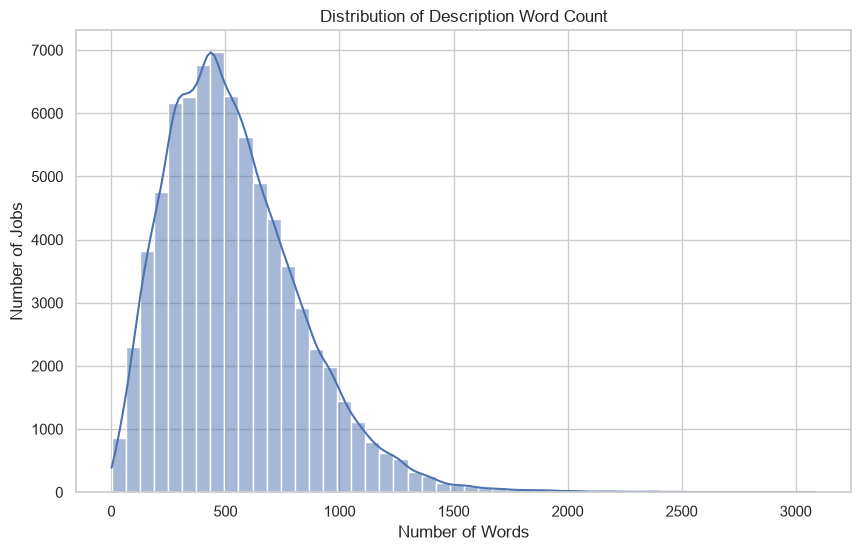

In [69]:
TEXT_COLUMNS = [
    "title",
    "description",
    "skills_desc"
]
available_text_columns = [
    col for col in TEXT_COLUMNS
    if col in X_train.columns
]
print("Available text columns:")
for col in available_text_columns:
    print(f"✓ {col}")

# ------------------------------------------------------------
# 1. Text feature functions
# ------------------------------------------------------------

def text_char_count(series):
    """
    Number of characters in each text.
    """
    return series.fillna("").astype(str).str.len()


def text_word_count(series):
    """
    Number of words in each text.
    """
    return (
        series
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )


def text_sentence_count(series):
    """
    Approximate number of sentences.
    """
    return (
        series
        .fillna("")
        .astype(str)
        .str.count(r"[.!?]")
    )

# ------------------------------------------------------------
# 2. Title features
# ------------------------------------------------------------

if "title" in X_train.columns:

    X_train["title_char_count"] = text_char_count(
        X_train["title"]
    )

    X_train["title_word_count"] = text_word_count(
        X_train["title"]
    )

    X_test["title_char_count"] = text_char_count(
        X_test["title"]
    )

    X_test["title_word_count"] = text_word_count(
        X_test["title"]
    )

# ------------------------------------------------------------
# 3. Description features
# ------------------------------------------------------------

if "description" in X_train.columns:

    X_train["description_char_count"] = text_char_count(
        X_train["description"]
    )

    X_train["description_word_count"] = text_word_count(
        X_train["description"]
    )

    X_train["description_sentence_count"] = text_sentence_count(
        X_train["description"]
    )

    X_test["description_char_count"] = text_char_count(
        X_test["description"]
    )

    X_test["description_word_count"] = text_word_count(
        X_test["description"]
    )

    X_test["description_sentence_count"] = text_sentence_count(
        X_test["description"]
    )

# ------------------------------------------------------------
# 4. Skills description features
# ------------------------------------------------------------

if "skills_desc" in X_train.columns:

    X_train["skills_desc_char_count"] = text_char_count(
        X_train["skills_desc"]
    )

    X_train["skills_desc_word_count"] = text_word_count(
        X_train["skills_desc"]
    )

    X_test["skills_desc_char_count"] = text_char_count(
        X_test["skills_desc"]
    )

    X_test["skills_desc_word_count"] = text_word_count(
        X_test["skills_desc"]
    )

# ------------------------------------------------------------
# 5. Inspect generated text features
# ------------------------------------------------------------

TEXT_STATISTICAL_FEATURES = [
    "title_char_count",
    "title_word_count",
    "description_char_count",
    "description_word_count",
    "description_sentence_count",
    "skills_desc_char_count",
    "skills_desc_word_count"
]

available_text_features = [
    col
    for col in TEXT_STATISTICAL_FEATURES
    if col in X_train.columns
]

print("Generated text statistical features:")

for col in available_text_features:
    print(f"✓ {col}")

print("\nNumber of text statistical features:",
      len(available_text_features))

# Xem dữ liệu
display(
    X_train[
        ["job_id"] + available_text_features
    ].head(10)
)

# Thống kê
display(
    X_train[
        available_text_features
    ].describe().T
)

# Visualize description length
plt.figure(figsize=(10, 6))

sns.histplot(
    X_train["description_word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Description Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Jobs")

plt.show()

# ------------------------------------------------------------
# 9. Text presence features
# ------------------------------------------------------------

if "description" in X_train.columns:

    X_train["has_description"] = (
        X_train["description"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .astype(int)
    )

    X_test["has_description"] = (
        X_test["description"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .astype(int)
    )


if "skills_desc" in X_train.columns:

    X_train["has_skills_desc"] = (
        X_train["skills_desc"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .astype(int)
    )

    X_test["has_skills_desc"] = (
        X_test["skills_desc"]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
        .astype(int)
    )

CELL 20 — Combine Features

In [71]:
# ============================================================
# CELL 20 — COMBINE ALL FEATURES
# ============================================================

from scipy.sparse import csr_matrix, hstack

# ------------------------------------------------------------
# 1. Numerical features
# ------------------------------------------------------------

print("Numerical:")
print(X_train_numeric_imputed.shape)
print(X_test_numeric_imputed.shape)

# ------------------------------------------------------------
# 2. Temporal features
# ------------------------------------------------------------

TEMPORAL_COLUMNS = [
    "listed_year",
    "listed_month",
    "listed_day",
    "listed_dayofweek",
    "listed_hour",
    "is_weekend"
]

available_temporal = [
    col
    for col in TEMPORAL_COLUMNS
    if col in X_train.columns
]

X_train_temporal = X_train[
    available_temporal
].copy()

X_test_temporal = X_test[
    available_temporal
].copy()

print("Temporal train shape:",
      X_train_temporal.shape)

print("Temporal test shape:",
      X_test_temporal.shape)

# ------------------------------------------------------------
# 3. Text statistical features
# ------------------------------------------------------------

X_train_text_stats = X_train[
    available_text_features
].copy()

X_test_text_stats = X_test[
    available_text_features
].copy()

print("Text statistics train shape:",
      X_train_text_stats.shape)

print("Text statistics test shape:",
      X_test_text_stats.shape)

# ------------------------------------------------------------
# 4. Check missing values
# ------------------------------------------------------------

print("Temporal missing:")
display(X_train_temporal.isna().sum())

print("\nText statistical missing:")
display(X_train_text_stats.isna().sum())

# ------------------------------------------------------------
# 5. Impute temporal + text statistical features
# ------------------------------------------------------------

from sklearn.impute import SimpleImputer

additional_imputer = SimpleImputer(
    strategy="median"
)

additional_train = pd.concat(
    [
        X_train_temporal,
        X_train_text_stats
    ],
    axis=1
)

additional_test = pd.concat(
    [
        X_test_temporal,
        X_test_text_stats
    ],
    axis=1
)

additional_train_imputed = (
    additional_imputer
    .fit_transform(additional_train)
)

additional_test_imputed = (
    additional_imputer
    .transform(additional_test)
)

print(
    "Additional train shape:",
    additional_train_imputed.shape
)

print(
    "Additional test shape:",
    additional_test_imputed.shape
)

# ------------------------------------------------------------
# 6. Convert dense features to sparse
# ------------------------------------------------------------

X_train_numeric_sparse = csr_matrix(
    X_train_numeric_imputed
)

X_test_numeric_sparse = csr_matrix(
    X_test_numeric_imputed
)

X_train_additional_sparse = csr_matrix(
    additional_train_imputed
)

X_test_additional_sparse = csr_matrix(
    additional_test_imputed
)

# ------------------------------------------------------------
# 7. Check all feature matrices
# ------------------------------------------------------------

print("FEATURE MATRICES")
print("-" * 50)

print(
    "TF-IDF:",
    X_train_tfidf.shape
)

print(
    "Skills:",
    X_train_skills.shape
)

print(
    "Categorical:",
    X_train_cat_encoded.shape
)

print(
    "Numerical:",
    X_train_numeric_sparse.shape
)

print(
    "Temporal + Text:",
    X_train_additional_sparse.shape
)

# ------------------------------------------------------------
# 8. Combine TRAIN features
# ------------------------------------------------------------

X_train_final = hstack(
    [
        X_train_tfidf,
        X_train_skills,
        X_train_cat_encoded,
        X_train_numeric_sparse,
        X_train_additional_sparse
    ],
    format="csr"
)

print(
    "Final X_train shape:",
    X_train_final.shape
)

# ------------------------------------------------------------
# 9. Combine TEST features
# ------------------------------------------------------------

X_test_final = hstack(
    [
        X_test_tfidf,
        X_test_skills,
        X_test_cat_encoded,
        X_test_numeric_sparse,
        X_test_additional_sparse
    ],
    format="csr"
)

print(
    "Final X_test shape:",
    X_test_final.shape
)

# ------------------------------------------------------------
# 10. Final shape validation
# ------------------------------------------------------------

print("=" * 60)
print("FINAL FEATURE MATRIX")
print("=" * 60)

print("X_train:", X_train_final.shape)
print("X_test :", X_test_final.shape)

print("\ny_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain samples match:")
print(X_train_final.shape[0] == y_train.shape[0])

print("\nTest samples match:")
print(X_test_final.shape[0] == y_test.shape[0])

# Kiểm tra sparse matrix
print("\nSparse matrix:")
print(X_train_final)

print("\nNumber of features:")
print(X_train_final.shape[1])

print("\nNumber of non-zero values:")
print(X_train_final.nnz)

Numerical:
(75552, 5)
(18888, 5)
Temporal train shape: (75552, 6)
Temporal test shape: (18888, 6)
Text statistics train shape: (75552, 7)
Text statistics test shape: (18888, 7)
Temporal missing:


listed_year         0
listed_month        0
listed_day          0
listed_dayofweek    0
listed_hour         0
is_weekend          0
dtype: int64


Text statistical missing:


title_char_count              0
title_word_count              0
description_char_count        0
description_word_count        0
description_sentence_count    0
skills_desc_char_count        0
skills_desc_word_count        0
dtype: int64

Additional train shape: (75552, 13)
Additional test shape: (18888, 13)
FEATURE MATRICES
--------------------------------------------------
TF-IDF: (75552, 30000)
Skills: (75552, 35)
Categorical: (75552, 7159)
Numerical: (75552, 5)
Temporal + Text: (75552, 13)
Final X_train shape: (75552, 37212)
Final X_test shape: (18888, 37212)
FINAL FEATURE MATRIX
X_train: (75552, 37212)
X_test : (18888, 37212)

y_train: (75552,)
y_test : (18888,)

Train samples match:
True

Test samples match:
True

Sparse matrix:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 27062573 stored elements and shape (75552, 37212)>
  Coords	Values
  (0, 148)	0.04597516468965926
  (0, 188)	0.0596612369073986
  (0, 196)	0.03799686505905749
  (0, 243)	0.027421762930431928
  (0, 334)	0.030462831780998612
  (0, 338)	0.056393120484024936
  (0, 346)	0.03529128780662498
  (0, 437)	0.035032213933981794
  (0, 669)	0.024913903285043563
  (0, 681)	0.04037124380897244
  (0, 1269)	0.06774937952378636
  (0, 1273)	0.06106

CELL 21 — Feature Selection

In [72]:
# ============================================================
# CELL 21 — FEATURE SELECTION
# ============================================================

from sklearn.feature_selection import SelectKBest, chi2

print("=" * 60)
print("FEATURE SELECTION")
print("=" * 60)

print("Original X_train shape:", X_train_final.shape)
print("Original X_test shape :", X_test_final.shape)

K_BEST = 10000

# ------------------------------------------------------------
# 1. Select number of features
# ------------------------------------------------------------

K_BEST = min(
    10000,
    X_train_final.shape[1]
)

print("Number of selected features:", K_BEST)

# ------------------------------------------------------------
# 2. Fit selector on TRAIN only
# ------------------------------------------------------------

feature_selector = SelectKBest(
    score_func=chi2,
    k=K_BEST
)

X_train_selected = feature_selector.fit_transform(
    X_train_final,
    y_train
)

print("Selected X_train shape:")
print(X_train_selected.shape)

# ------------------------------------------------------------
# 3. Transform TEST
# ------------------------------------------------------------

X_test_selected = feature_selector.transform(
    X_test_final
)

print("Selected X_test shape:")
print(X_test_selected.shape)

# ------------------------------------------------------------
# 4. Validate selected features
# ------------------------------------------------------------

print("=" * 60)
print("FEATURE SELECTION RESULT")
print("=" * 60)

print("Before selection:")
print("Train:", X_train_final.shape)
print("Test :", X_test_final.shape)

print("\nAfter selection:")
print("Train:", X_train_selected.shape)
print("Test :", X_test_selected.shape)

print("\nTrain samples match:")
print(X_train_selected.shape[0] == y_train.shape[0])

print("\nTest samples match:")
print(X_test_selected.shape[0] == y_test.shape[0])

# ------------------------------------------------------------
# 5. Get selected feature indices
# ------------------------------------------------------------

selected_indices = feature_selector.get_support(
    indices=True
)

print("Number of selected features:")
print(len(selected_indices))

print("\nFirst 50 selected feature indices:")
print(selected_indices[:50])

# ------------------------------------------------------------
# 6. Feature scores
# ------------------------------------------------------------

feature_scores = feature_selector.scores_

selected_scores = pd.DataFrame({
    "feature_index": selected_indices,
    "chi2_score": feature_scores[selected_indices]
})

selected_scores = selected_scores.sort_values(
    "chi2_score",
    ascending=False
)

display(
    selected_scores.head(50)
)



FEATURE SELECTION
Original X_train shape: (75552, 37212)
Original X_test shape : (18888, 37212)
Number of selected features: 10000
Selected X_train shape:
(75552, 10000)
Selected X_test shape:
(18888, 10000)
FEATURE SELECTION RESULT
Before selection:
Train: (75552, 37212)
Test : (18888, 37212)

After selection:
Train: (75552, 10000)
Test : (18888, 10000)

Train samples match:
True

Test samples match:
True
Number of selected features:
10000

First 50 selected feature indices:
[  1   2   4   5   6  26  27  29  38  42  47  51  59  65  71  76  83  85
  89  92  96  98 103 105 106 115 124 129 131 136 137 138 139 142 144 146
 148 165 171 175 179 180 181 182 184 188 190 192 196 198]


,feature_index,chi2_score
9990,37196,1.011758e+08
9991,37197,7.606223e+07
9988,37194,7.171811e+07
9989,37195,1.454204e+07
9995,37207,1.140786e+06
9996,37208,1.471340e+05
9998,37210,3.553846e+04
8286,30037,1.950158e+04
8293,30044,6.504138e+03
9997,37209,5.259058e+03


In [73]:
# ============================================================
# CELL 21.1 — FEATURE NAMES
# ============================================================

# TF-IDF feature names
tfidf_feature_names = np.array([
    f"tfidf__{name}"
    for name in tfidf.get_feature_names_out()
])

# Skill feature names
skill_feature_names = np.array([
    f"skill__{name}"
    for name in mlb.classes_
])

# Categorical feature names
categorical_feature_names = np.array([
    f"categorical__{name}"
    for name in categorical_feature_names
])

# Numerical feature names
numeric_feature_names = np.array(
    NUMERICAL_COLUMNS
)

# Temporal + text statistical feature names
additional_feature_names = np.array(
    list(additional_train.columns)
)

# Combine names
all_feature_names = np.concatenate([
    tfidf_feature_names,
    skill_feature_names,
    categorical_feature_names,
    numeric_feature_names,
    additional_feature_names
])

print("Number of feature names:")
print(len(all_feature_names))

print("Number of columns in X_train_final:")
print(X_train_final.shape[1])

print("\nNames match:")
print(
    len(all_feature_names) ==
    X_train_final.shape[1]
)

Number of feature names:
37212
Number of columns in X_train_final:
37212

Names match:
True


In [74]:
# ============================================================
# CELL 21.2 — SELECTED FEATURE NAMES
# ============================================================

selected_feature_names = all_feature_names[
    feature_selector.get_support()
]

selected_feature_scores = feature_selector.scores_[
    feature_selector.get_support()
]

selected_features_df = pd.DataFrame({
    "feature": selected_feature_names,
    "chi2_score": selected_feature_scores
})

selected_features_df = (
    selected_features_df
    .sort_values(
        "chi2_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    selected_features_df.head(50)
)

,feature,chi2_score
0,max_salary,1.011758e+08
1,normalized_salary,7.606223e+07
2,min_salary,7.171811e+07
3,med_salary,1.454204e+07
4,description_char_count,1.140786e+06
5,description_word_count,1.471340e+05
6,skills_desc_char_count,3.553846e+04
7,categorical__formatted_work_type_Internship,1.950158e+04
8,categorical__application_type_ComplexOnsiteApply,6.504138e+03
9,description_sentence_count,5.259058e+03


CELL 22 — Leakage Check

In [81]:
# Kiểm tra target có lọt vào feature không
print("=" * 60)
print("LEAKAGE CHECK")
print("=" * 60)

TARGET = "formatted_experience_level"

print("Target:", TARGET)

# Kiểm tra target có xuất hiện trong X_train không
if TARGET in X_train.columns:
    print(f"⚠️ WARNING: Target '{TARGET}' is still present in X_train!")
else:
    print(f"✓ Target '{TARGET}' is NOT present in X_train.")

if TARGET in X_test.columns:
    print(f"⚠️ WARNING: Target '{TARGET}' is still present in X_test!")
else:
    print(f"✓ Target '{TARGET}' is NOT present in X_test.")

# Kiểm tra các cột có khả năng gây leakage
POTENTIAL_LEAKAGE_COLUMNS = [
    "formatted_experience_level",
    "experience_level",
    "closed_time",
    "expiry"
]

print("\nPotential leakage columns:")
for col in POTENTIAL_LEAKAGE_COLUMNS:
    if col in X_train.columns:
        print(f"⚠️ {col} is present")
    else:
        print(f"✓ {col} is not present")

# Kiểm tra relationship giữa experience_level và target
if "formatted_experience_level" in data.columns and TARGET in data.columns:

    print("=" * 60)
    print("EXPERIENCE LEVEL vs TARGET")
    print("=" * 60)

    leakage_table = pd.crosstab(
        data["formatted_experience_level"],
        data[TARGET],
        normalize="index"
    )

    display(leakage_table)

# Kiểm tra temporal leakage
TEMPORAL_LEAKAGE_COLUMNS = [
    "expiry",
    "closed_time"
]

print("=" * 60)
print("TEMPORAL LEAKAGE CHECK")
print("=" * 60)

for col in TEMPORAL_LEAKAGE_COLUMNS:
    if col in X_train.columns:
        print(f"⚠️ {col} should be reviewed for temporal leakage.")
    else:
        print(f"✓ {col} is not used.")

# Kiểm tra feature matrix sau Feature Selection
print("=" * 60)
print("FINAL FEATURE MATRIX CHECK")
print("=" * 60)

print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape :", X_test_selected.shape)

print("\nTarget shape:")
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nRow consistency:")

print(
    "Train:",
    X_train_selected.shape[0] == y_train.shape[0]
)

print(
    "Test :",
    X_test_selected.shape[0] == y_test.shape[0]
)
# Tổng kết Leakage Check
print("=" * 60)
print("LEAKAGE CHECK SUMMARY")
print("=" * 60)

checks = {
    "Target absent from X_train": TARGET not in X_train.columns,
    "Target absent from X_test": TARGET not in X_test.columns,
    "Train/Test row count consistent": (
        X_train_selected.shape[0] == y_train.shape[0]
        and X_test_selected.shape[0] == y_test.shape[0]
    ),
    "TF-IDF fitted only on train": True,
    "Skill encoder fitted only on train": True,
    "Categorical encoder fitted only on train": True,
    "Feature selector fitted only on train": True
}

for check, result in checks.items():
    print(f"{'✓' if result else '⚠️'} {check}")
    

LEAKAGE CHECK
Target: formatted_experience_level
✓ Target 'formatted_experience_level' is NOT present in X_train.
✓ Target 'formatted_experience_level' is NOT present in X_test.

Potential leakage columns:
✓ formatted_experience_level is not present
✓ experience_level is not present
⚠️ closed_time is present
⚠️ expiry is present
EXPERIENCE LEVEL vs TARGET


formatted_experience_level,Associate,Director,Entry level,Executive,Internship,Mid-Senior level
formatted_experience_level,,,,,,
Associate,1.0,0.0,0.0,0.0,0.0,0.0
Director,0.0,1.0,0.0,0.0,0.0,0.0
Entry level,0.0,0.0,1.0,0.0,0.0,0.0
Executive,0.0,0.0,0.0,1.0,0.0,0.0
Internship,0.0,0.0,0.0,0.0,1.0,0.0
Mid-Senior level,0.0,0.0,0.0,0.0,0.0,1.0


TEMPORAL LEAKAGE CHECK
⚠️ expiry should be reviewed for temporal leakage.
⚠️ closed_time should be reviewed for temporal leakage.
FINAL FEATURE MATRIX CHECK
X_train_selected shape: (75552, 10000)
X_test_selected shape : (18888, 10000)

Target shape:
y_train: (75552,)
y_test : (18888,)

Row consistency:
Train: True
Test : True
LEAKAGE CHECK SUMMARY
✓ Target absent from X_train
✓ Target absent from X_test
✓ Train/Test row count consistent
✓ TF-IDF fitted only on train
✓ Skill encoder fitted only on train
✓ Categorical encoder fitted only on train
✓ Feature selector fitted only on train


CELL 23 — Final Feature Validation


In [82]:
# ============================================================
# CELL 23 - FINAL FEATURE VALIDATION
# ============================================================

import numpy as np
from scipy.sparse import issparse

print("=" * 60)
print("FINAL FEATURE VALIDATION")
print("=" * 60)


# ============================================================
# 1. CHECK SHAPE
# ============================================================

print("\n[1] FEATURE SHAPE")
print("-" * 60)

print("X_train_selected shape:", X_train_selected.shape)
print("X_test_selected shape :", X_test_selected.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


# ============================================================
# 2. CHECK NUMBER OF SAMPLES
# ============================================================

print("\n[2] SAMPLE CONSISTENCY")
print("-" * 60)

train_samples_match = (
    X_train_selected.shape[0] == len(y_train)
)

test_samples_match = (
    X_test_selected.shape[0] == len(y_test)
)

print(
    f"Train samples match: {train_samples_match}"
)

print(
    f"Test samples match : {test_samples_match}"
)


# ============================================================
# 3. CHECK NUMBER OF FEATURES
# ============================================================

print("\n[3] FEATURE CONSISTENCY")
print("-" * 60)

train_features = X_train_selected.shape[1]
test_features = X_test_selected.shape[1]

print("Train features:", train_features)
print("Test features :", test_features)

feature_count_match = (
    train_features == test_features
)

print(
    f"Feature count match: {feature_count_match}"
)


# ============================================================
# 4. CHECK SPARSE MATRIX
# ============================================================

print("\n[4] SPARSE MATRIX CHECK")
print("-" * 60)

train_is_sparse = issparse(X_train_selected)
test_is_sparse = issparse(X_test_selected)

print(
    f"X_train_selected is sparse: {train_is_sparse}"
)

print(
    f"X_test_selected is sparse : {test_is_sparse}"
)


# ============================================================
# 5. CHECK NaN
# ============================================================

print("\n[5] NaN CHECK")
print("-" * 60)

train_nan = np.isnan(
    X_train_selected.data
).sum()

test_nan = np.isnan(
    X_test_selected.data
).sum()

print("NaN in X_train:", train_nan)
print("NaN in X_test :", test_nan)

nan_check = (
    train_nan == 0 and
    test_nan == 0
)

print(
    f"NaN check passed: {nan_check}"
)


# ============================================================
# 6. CHECK INFINITY
# ============================================================

print("\n[6] INFINITY CHECK")
print("-" * 60)

train_inf = np.isinf(
    X_train_selected.data
).sum()

test_inf = np.isinf(
    X_test_selected.data
).sum()

print("Inf in X_train:", train_inf)
print("Inf in X_test :", test_inf)

inf_check = (
    train_inf == 0 and
    test_inf == 0
)

print(
    f"Infinity check passed: {inf_check}"
)


# ============================================================
# 7. CHECK EMPTY FEATURES
# ============================================================

print("\n[7] EMPTY FEATURE CHECK")
print("-" * 60)

train_has_features = X_train_selected.shape[1] > 0
test_has_features = X_test_selected.shape[1] > 0

print(
    f"Train has features: {train_has_features}"
)

print(
    f"Test has features : {test_has_features}"
)


# ============================================================
# 8. CHECK TARGET
# ============================================================

print("\n[8] TARGET VALIDATION")
print("-" * 60)

print("Number of training samples:", len(y_train))
print("Number of test samples:", len(y_test))

print(
    "Training target missing:",
    y_train.isna().sum()
)

print(
    "Test target missing:",
    y_test.isna().sum()
)

target_check = (
    y_train.isna().sum() == 0 and
    y_test.isna().sum() == 0
)

print(
    f"Target validation passed: {target_check}"
)


# ============================================================
# 9. FINAL VALIDATION RESULT
# ============================================================

print("\n" + "=" * 60)
print("FINAL VALIDATION RESULT")
print("=" * 60)

all_checks = {
    "Train samples match target": train_samples_match,
    "Test samples match target": test_samples_match,
    "Train/Test feature count match": feature_count_match,
    "Train matrix is sparse": train_is_sparse,
    "Test matrix is sparse": test_is_sparse,
    "No NaN in train features": nan_check,
    "No Inf in train features": inf_check,
    "Train has features": train_has_features,
    "Test has features": test_has_features,
    "Target has no missing values": target_check
}

for check, result in all_checks.items():
    symbol = "✓" if result else "⚠️"
    print(f"{symbol} {check}: {result}")


# ============================================================
# 10. FINAL DECISION
# ============================================================

print("\n" + "=" * 60)

if all(all_checks.values()):
    print("✓ FINAL FEATURE VALIDATION PASSED")
    print("✓ Features are ready to be saved.")
    print("✓ Features are ready for modeling.")

else:
    print("⚠️ FINAL FEATURE VALIDATION FAILED")
    print("⚠️ Review the failed checks before modeling.")

print("=" * 60)

FINAL FEATURE VALIDATION

[1] FEATURE SHAPE
------------------------------------------------------------
X_train_selected shape: (75552, 10000)
X_test_selected shape : (18888, 10000)
y_train shape: (75552,)
y_test shape : (18888,)

[2] SAMPLE CONSISTENCY
------------------------------------------------------------
Train samples match: True
Test samples match : True

[3] FEATURE CONSISTENCY
------------------------------------------------------------
Train features: 10000
Test features : 10000
Feature count match: True

[4] SPARSE MATRIX CHECK
------------------------------------------------------------
X_train_selected is sparse: True
X_test_selected is sparse : True

[5] NaN CHECK
------------------------------------------------------------
NaN in X_train: 0
NaN in X_test : 0
NaN check passed: True

[6] INFINITY CHECK
------------------------------------------------------------
Inf in X_train: 0
Inf in X_test : 0
Infinity check passed: True

[7] EMPTY FEATURE CHECK
-------------------

CELL 24 — Save Features

In [83]:
# ============================================================
# CELL 24 - SAVE FEATURES
# ============================================================

import os
import joblib
from scipy.sparse import save_npz

print("=" * 60)
print("SAVE FINAL FEATURES")
print("=" * 60)


# ============================================================
# 1. CREATE OUTPUT DIRECTORY
# ============================================================

FEATURE_DIR = "../data/processed/features"

os.makedirs(FEATURE_DIR, exist_ok=True)

print("\nFeature output directory:")
print(os.path.abspath(FEATURE_DIR))


# ============================================================
# 2. SAVE FEATURE MATRICES
# ============================================================

print("\n[1] SAVING FEATURE MATRICES")
print("-" * 60)

train_feature_path = os.path.join(
    FEATURE_DIR,
    "X_train_selected.npz"
)

test_feature_path = os.path.join(
    FEATURE_DIR,
    "X_test_selected.npz"
)

save_npz(
    train_feature_path,
    X_train_selected
)

save_npz(
    test_feature_path,
    X_test_selected
)

print(f"✓ Saved: {train_feature_path}")
print(f"✓ Saved: {test_feature_path}")


# ============================================================
# 3. SAVE TARGET
# ============================================================

print("\n[2] SAVING TARGET")
print("-" * 60)

y_train_path = os.path.join(
    FEATURE_DIR,
    "y_train.csv"
)

y_test_path = os.path.join(
    FEATURE_DIR,
    "y_test.csv"
)

y_train.to_csv(
    y_train_path,
    index=False
)

y_test.to_csv(
    y_test_path,
    index=False
)

print(f"✓ Saved: {y_train_path}")
print(f"✓ Saved: {y_test_path}")


# ============================================================
# 4. SAVE FEATURE SELECTOR
# ============================================================

print("\n[3] SAVING FEATURE SELECTOR")
print("-" * 60)

selector_path = os.path.join(
    FEATURE_DIR,
    "feature_selector.pkl"
)

joblib.dump(
    feature_selector,
    selector_path
)

print(f"✓ Saved: {selector_path}")


# ============================================================
# 5. SAVE TF-IDF VECTORIZER
# ============================================================

print("\n[4] SAVING TF-IDF VECTORIZER")
print("-" * 60)

tfidf_path = os.path.join(
    FEATURE_DIR,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    tfidf,
    tfidf_path
)

print(f"✓ Saved: {tfidf_path}")


# ============================================================
# 6. SAVE SKILL ENCODER
# ============================================================

print("\n[5] SAVING SKILL ENCODER")
print("-" * 60)

mlb_path = os.path.join(
    FEATURE_DIR,
    "skill_encoder.pkl"
)

joblib.dump(
    mlb,
    mlb_path
)

print(f"✓ Saved: {mlb_path}")


# ============================================================
# 7. SAVE CATEGORICAL IMPUTER + ENCODER
# ============================================================

print("\n[6] SAVING CATEGORICAL PREPROCESSING")
print("-" * 60)

categorical_imputer_path = os.path.join(
    FEATURE_DIR,
    "categorical_imputer.pkl"
)

categorical_encoder_path = os.path.join(
    FEATURE_DIR,
    "categorical_encoder.pkl"
)

joblib.dump(
    categorical_imputer,
    categorical_imputer_path
)

joblib.dump(
    categorical_encoder,
    categorical_encoder_path
)

print(f"✓ Saved: {categorical_imputer_path}")
print(f"✓ Saved: {categorical_encoder_path}")


# ============================================================
# 8. SAVE NUMERICAL IMPUTER
# ============================================================

print("\n[7] SAVING NUMERICAL IMPUTER")
print("-" * 60)

numeric_imputer_path = os.path.join(
    FEATURE_DIR,
    "numeric_imputer.pkl"
)

joblib.dump(
    numeric_imputer,
    numeric_imputer_path
)

print(f"✓ Saved: {numeric_imputer_path}")


# ============================================================
# 9. SAVE ADDITIONAL IMPUTER
# ============================================================

print("\n[8] SAVING ADDITIONAL IMPUTER")
print("-" * 60)

additional_imputer_path = os.path.join(
    FEATURE_DIR,
    "additional_imputer.pkl"
)

joblib.dump(
    additional_imputer,
    additional_imputer_path
)

print(f"✓ Saved: {additional_imputer_path}")


# ============================================================
# 10. SAVE FEATURE NAMES
# ============================================================

print("\n[9] SAVING FEATURE NAMES")
print("-" * 60)

selected_feature_names_path = os.path.join(
    FEATURE_DIR,
    "selected_feature_names.pkl"
)

joblib.dump(
    selected_feature_names,
    selected_feature_names_path
)

print(f"✓ Saved: {selected_feature_names_path}")


# ============================================================
# 11. SAVE FEATURE METADATA
# ============================================================

print("\n[10] SAVING FEATURE METADATA")
print("-" * 60)

feature_metadata = {
    "train_shape": X_train_selected.shape,
    "test_shape": X_test_selected.shape,
    "num_features": X_train_selected.shape[1],
    "num_train_samples": X_train_selected.shape[0],
    "num_test_samples": X_test_selected.shape[0],
    "target": TARGET,
    "tfidf_features": X_train_tfidf.shape[1],
    "skill_features": X_train_skills.shape[1],
    "categorical_features": X_train_cat_encoded.shape[1],
    "selected_features": X_train_selected.shape[1]
}

metadata_path = os.path.join(
    FEATURE_DIR,
    "feature_metadata.pkl"
)

joblib.dump(
    feature_metadata,
    metadata_path
)

print(f"✓ Saved: {metadata_path}")


# ============================================================
# 12. VERIFY SAVED FILES
# ============================================================

print("\n" + "=" * 60)
print("VERIFY SAVED FILES")
print("=" * 60)

for filename in sorted(os.listdir(FEATURE_DIR)):
    filepath = os.path.join(FEATURE_DIR, filename)

    if os.path.isfile(filepath):
        size_kb = os.path.getsize(filepath) / 1024

        print(
            f"✓ {filename:<35} "
            f"{size_kb:,.2f} KB"
        )


# ============================================================
# 13. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FEATURE SAVING COMPLETED")
print("=" * 60)

print(f"Train features : {X_train_selected.shape}")
print(f"Test features  : {X_test_selected.shape}")
print(f"Train target   : {y_train.shape}")
print(f"Test target    : {y_test.shape}")

print("\nOutput directory:")
print(os.path.abspath(FEATURE_DIR))

print("\n✓ Feature Engineering pipeline completed.")
print("✓ Final features are ready for modeling.")

SAVE FINAL FEATURES

Feature output directory:
d:\AI_LAB\DS_Job_Recommend_Projects\data\processed\features

[1] SAVING FEATURE MATRICES
------------------------------------------------------------
✓ Saved: ../data/processed/features\X_train_selected.npz
✓ Saved: ../data/processed/features\X_test_selected.npz

[2] SAVING TARGET
------------------------------------------------------------
✓ Saved: ../data/processed/features\y_train.csv
✓ Saved: ../data/processed/features\y_test.csv

[3] SAVING FEATURE SELECTOR
------------------------------------------------------------
✓ Saved: ../data/processed/features\feature_selector.pkl

[4] SAVING TF-IDF VECTORIZER
------------------------------------------------------------
✓ Saved: ../data/processed/features\tfidf_vectorizer.pkl

[5] SAVING SKILL ENCODER
------------------------------------------------------------
✓ Saved: ../data/processed/features\skill_encoder.pkl

[6] SAVING CATEGORICAL PREPROCESSING
-----------------------------------------